# 05 - Random Forest

Ensemble de árvores de decisão. Espera-se maior capacidade de capturar interações não-lineares entre via, clima e veículo do que a Regressão Logística, ao custo de menor interpretabilidade direta e maior tempo de treino.

## 1. Importações

In [1]:
import sys
sys.path.append('../src')

import time
import json
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score
)

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")


✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Preparação dos Dados

In [2]:
X_train, X_test, y_train, y_test = carregar_dados()

print(f"Registros de treino: {X_train.shape[0]} | Registros de teste: {X_test.shape[0]}")
print(f"Total de features após encoding: {X_train.shape[1]}")


Registros de treino: 151713 | Registros de teste: 65021
Total de features após encoding: 77


## 3. Treinamento do Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

tempo_inicio = time.time()
modelo.fit(X_train, y_train)
tempo_treino = time.time() - tempo_inicio

print(f"✅ Random Forest treinado em {tempo_treino:.3f} segundos!")


✅ Random Forest treinado em 11.481 segundos!


## 4. Avaliação do Modelo

--- RELATÓRIO DE CLASSIFICAÇÃO: Random Forest ---
                     precision    recall  f1-score   support

0: Leve/Sem Vítimas       0.92      0.92      0.92     56583
     1: Grave/Fatal       0.44      0.44      0.44      8438

           accuracy                           0.85     65021
          macro avg       0.68      0.68      0.68     65021
       weighted avg       0.85      0.85      0.85     65021



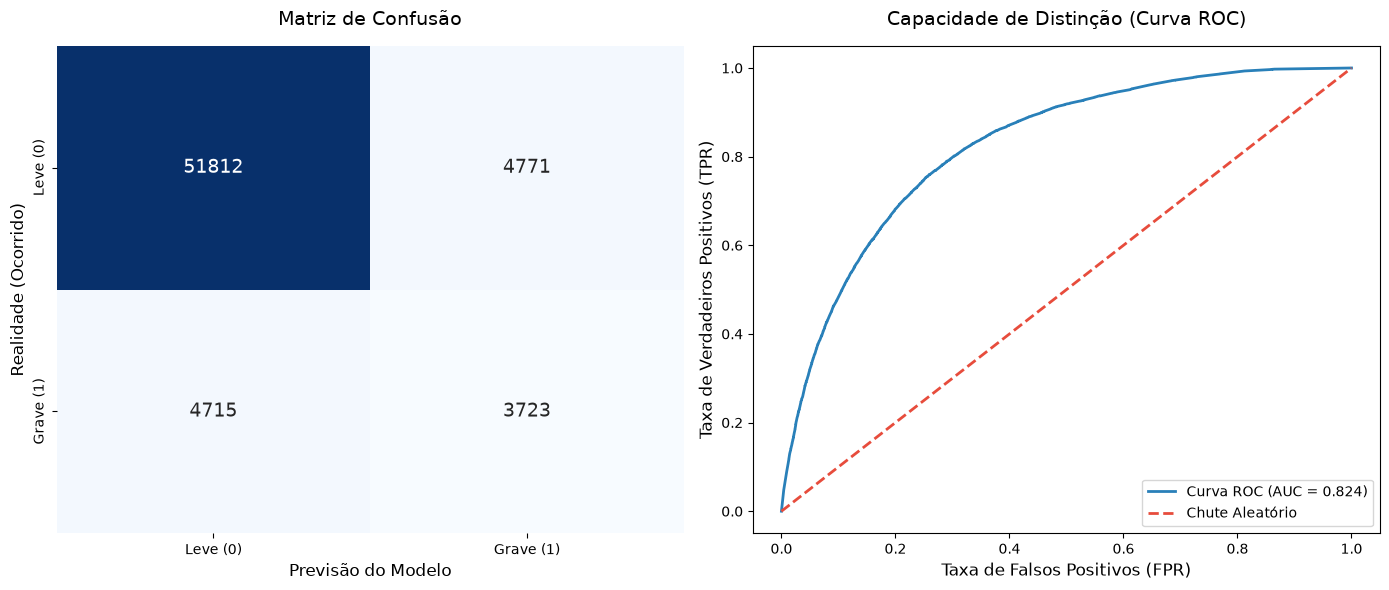

Acurácia: 0.8541 | Precision: 0.4383 | Recall: 0.4412 | AUC: 0.8242


In [4]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("--- RELATÓRIO DE CLASSIFICAÇÃO: Random Forest ---")
print(classification_report(y_test, y_pred, target_names=['0: Leve/Sem Vítimas', '1: Grave/Fatal']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Leve (0)', 'Grave (1)'],
            yticklabels=['Leve (0)', 'Grave (1)'],
            cbar=False, annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15)
axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
axes[0].set_ylabel('Realidade (Ocorrido)', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Chute Aleatório')
axes[1].set_title('Capacidade de Distinção (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Acurácia: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | AUC: {auc:.4f}")


## 5. Importância das Variáveis

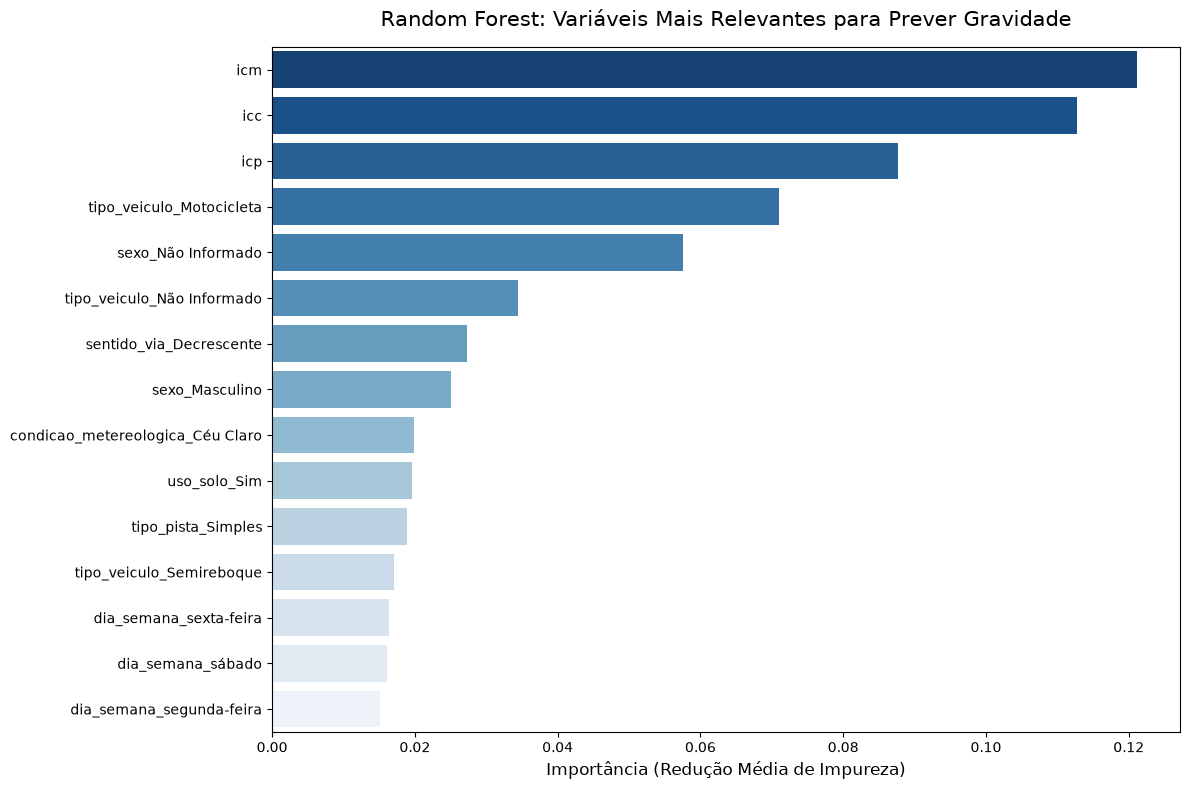

In [5]:
importancias = pd.DataFrame({
    'Variavel': X_train.columns,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importancias.head(15), x='Importancia', y='Variavel', palette='Blues_r')
plt.title('Random Forest: Variáveis Mais Relevantes para Prever Gravidade', fontsize=15, pad=15)
plt.xlabel('Importância (Redução Média de Impureza)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()


## 6. Exportação do Modelo e das Métricas

In [6]:
os.makedirs('../models', exist_ok=True)

joblib.dump(modelo, '../models/modelo_random_forest.pkl')
joblib.dump(X_train.columns.tolist(), '../models/colunas_treino.pkl')

resultado = {
    'chave': 'random_forest',
    'algoritmo': 'Random Forest',
    'acuracia': round(float(acc), 4),
    'precision': round(float(prec), 4),
    'recall': round(float(rec), 4),
    'auc_score': round(float(auc), 4),
    'tempo_segundos': round(float(tempo_treino), 4),
}

with open('../models/resultados_random_forest.json', 'w', encoding='utf-8') as f:
    json.dump(resultado, f, ensure_ascii=False, indent=2)

print(f"✅ Modelo e métricas de Random Forest exportados com sucesso!")
resultado


✅ Modelo e métricas de Random Forest exportados com sucesso!


{'chave': 'random_forest',
 'algoritmo': 'Random Forest',
 'acuracia': 0.8541,
 'precision': 0.4383,
 'recall': 0.4412,
 'auc_score': 0.8242,
 'tempo_segundos': 11.4813}